In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q ultralytics scikit-learn pandas matplotlib

import os, shutil, zipfile
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from IPython.display import Image, display

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 80.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
ZIP_PATH = "/content/drive/MyDrive/Dataset_Classification_Gan.zip"
UNZIP_DIR = "/content/Dataset_Classification_Gan"
SAVE_DIR = "/content/drive/MyDrive/YOLO_Classification_Gan_Result"

if os.path.exists(UNZIP_DIR):
    shutil.rmtree(UNZIP_DIR)

os.makedirs(UNZIP_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(UNZIP_DIR)

print("Đã unzip xong")

Đã unzip xong


In [3]:
def find_dataset_root(base):
    base = Path(base)

    if (base / "train").exists():
        return base

    for p in base.rglob("*"):
        if p.is_dir() and (p / "train").exists():
            return p

    raise Exception("Không tìm thấy thư mục train trong dataset")

DATA_DIR = find_dataset_root(UNZIP_DIR)

# Nếu thư mục validation tên là valid thì đổi thành val
if (DATA_DIR / "valid").exists() and not (DATA_DIR / "val").exists():
    shutil.copytree(DATA_DIR / "valid", DATA_DIR / "val")

print("Dataset:", DATA_DIR)

Dataset: /content/Dataset_Classification_Gan/Dataset_Classification_Gan


In [4]:
model = YOLO("yolo11n-cls.pt")

model.train(
    data=str(DATA_DIR),
    epochs=100,
    imgsz=640,
    batch=16,

    project=SAVE_DIR,
    name="train",
    plots=True,
    exist_ok=True
)

RESULT_DIR = Path(SAVE_DIR) / "train"

print("Train xong")
print("Best:", RESULT_DIR / "weights" / "best.pt")
print("Last:", RESULT_DIR / "weights" / "last.pt")

Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Dataset_Classification_Gan/Dataset_Classification_Gan, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=

In [5]:
best_model = YOLO(str(RESULT_DIR / "weights" / "best.pt"))

# Ưu tiên test, nếu không có thì dùng val
if (DATA_DIR / "test").exists():
    EVAL_DIR = DATA_DIR / "test"
    split_name = "test"
else:
    EVAL_DIR = DATA_DIR / "val"
    split_name = "val"

img_exts = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
image_paths = [p for p in EVAL_DIR.rglob("*") if p.suffix.lower() in img_exts]

y_true = []
y_pred = []

for img_path in image_paths:
    result = best_model.predict(str(img_path), imgsz=640, verbose=False)[0]

    true_class = img_path.parent.name
    pred_class = best_model.names[int(result.probs.top1)]

    y_true.append(true_class)
    y_pred.append(pred_class)

labels = sorted(list(set(y_true) | set(y_pred)))

acc = accuracy_score(y_true, y_pred)
pre = precision_score(y_true, y_pred, average="macro", zero_division=0)
rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [acc, pre, rec, f1]
})

summary.to_csv(RESULT_DIR / f"classification_metrics_{split_name}.csv", index=False)

report = classification_report(
    y_true,
    y_pred,
    labels=labels,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()
report_df.to_csv(RESULT_DIR / f"classification_report_{split_name}.csv")

display(summary)
display(report_df)

print("Đã lưu file metrics vào:", RESULT_DIR)

,Metric,Value
0,Accuracy,0.974638
1,Precision,0.920677
2,Recall,0.916667
3,F1-score,0.915699


,precision,recall,f1-score,support
PCB OK,0.705882,0.857143,0.774194,14.000000
PCB_Missing_CP2102,1.000000,1.000000,1.000000,14.000000
PCB_Missing_Capacitor,1.000000,1.000000,1.000000,118.000000
PCB_Missing_ESP32,1.000000,1.000000,1.000000,14.000000
PCB_Missing_Resistor,1.000000,1.000000,1.000000,102.000000
PCB_Missing_USB,0.818182,0.642857,0.720000,14.000000
accuracy,0.974638,0.974638,0.974638,0.974638
macro avg,0.920677,0.916667,0.915699,276.000000
weighted avg,0.975858,0.974638,0.974343,276.000000


Đã lưu file metrics vào: /content/drive/MyDrive/YOLO_Classification_Gan_Result/train


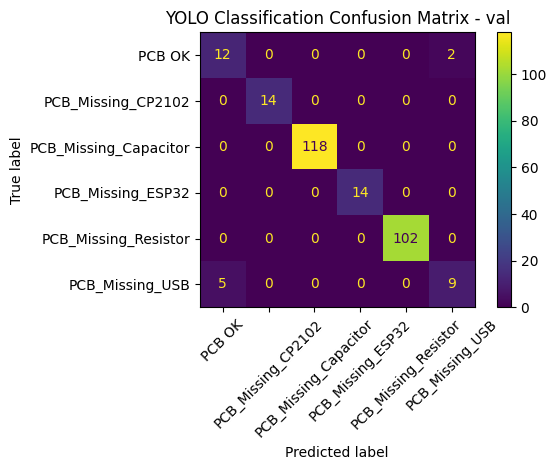

In [6]:
cm = confusion_matrix(y_true, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(xticks_rotation=45)

plt.title(f"YOLO Classification Confusion Matrix - {split_name}")
plt.tight_layout()
plt.savefig(RESULT_DIR / f"classification_confusion_matrix_{split_name}.png", dpi=300)
plt.show()

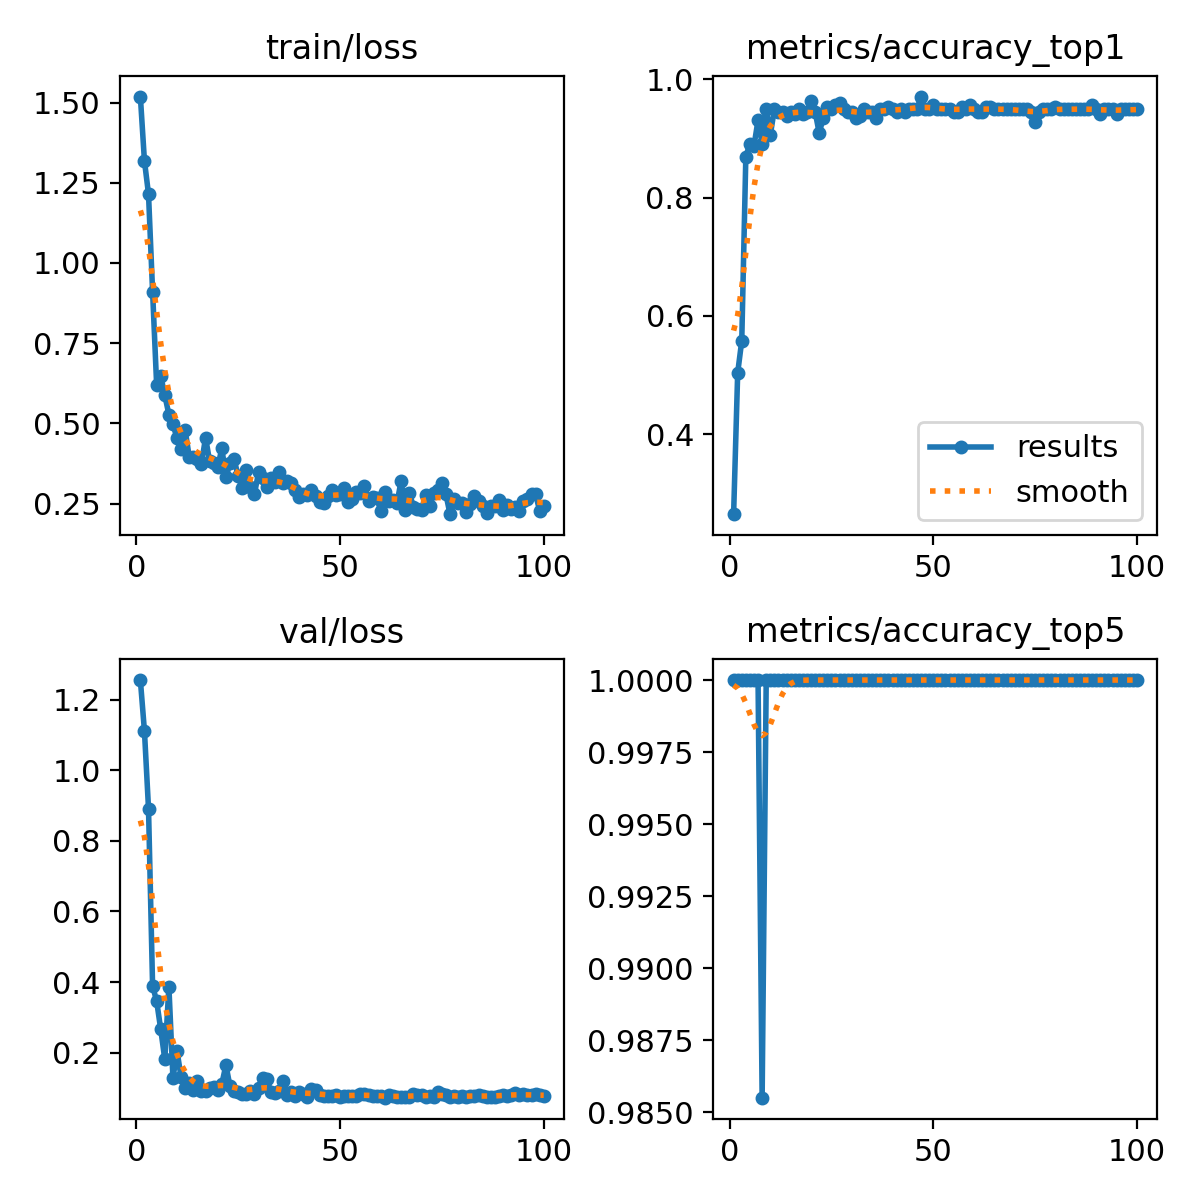

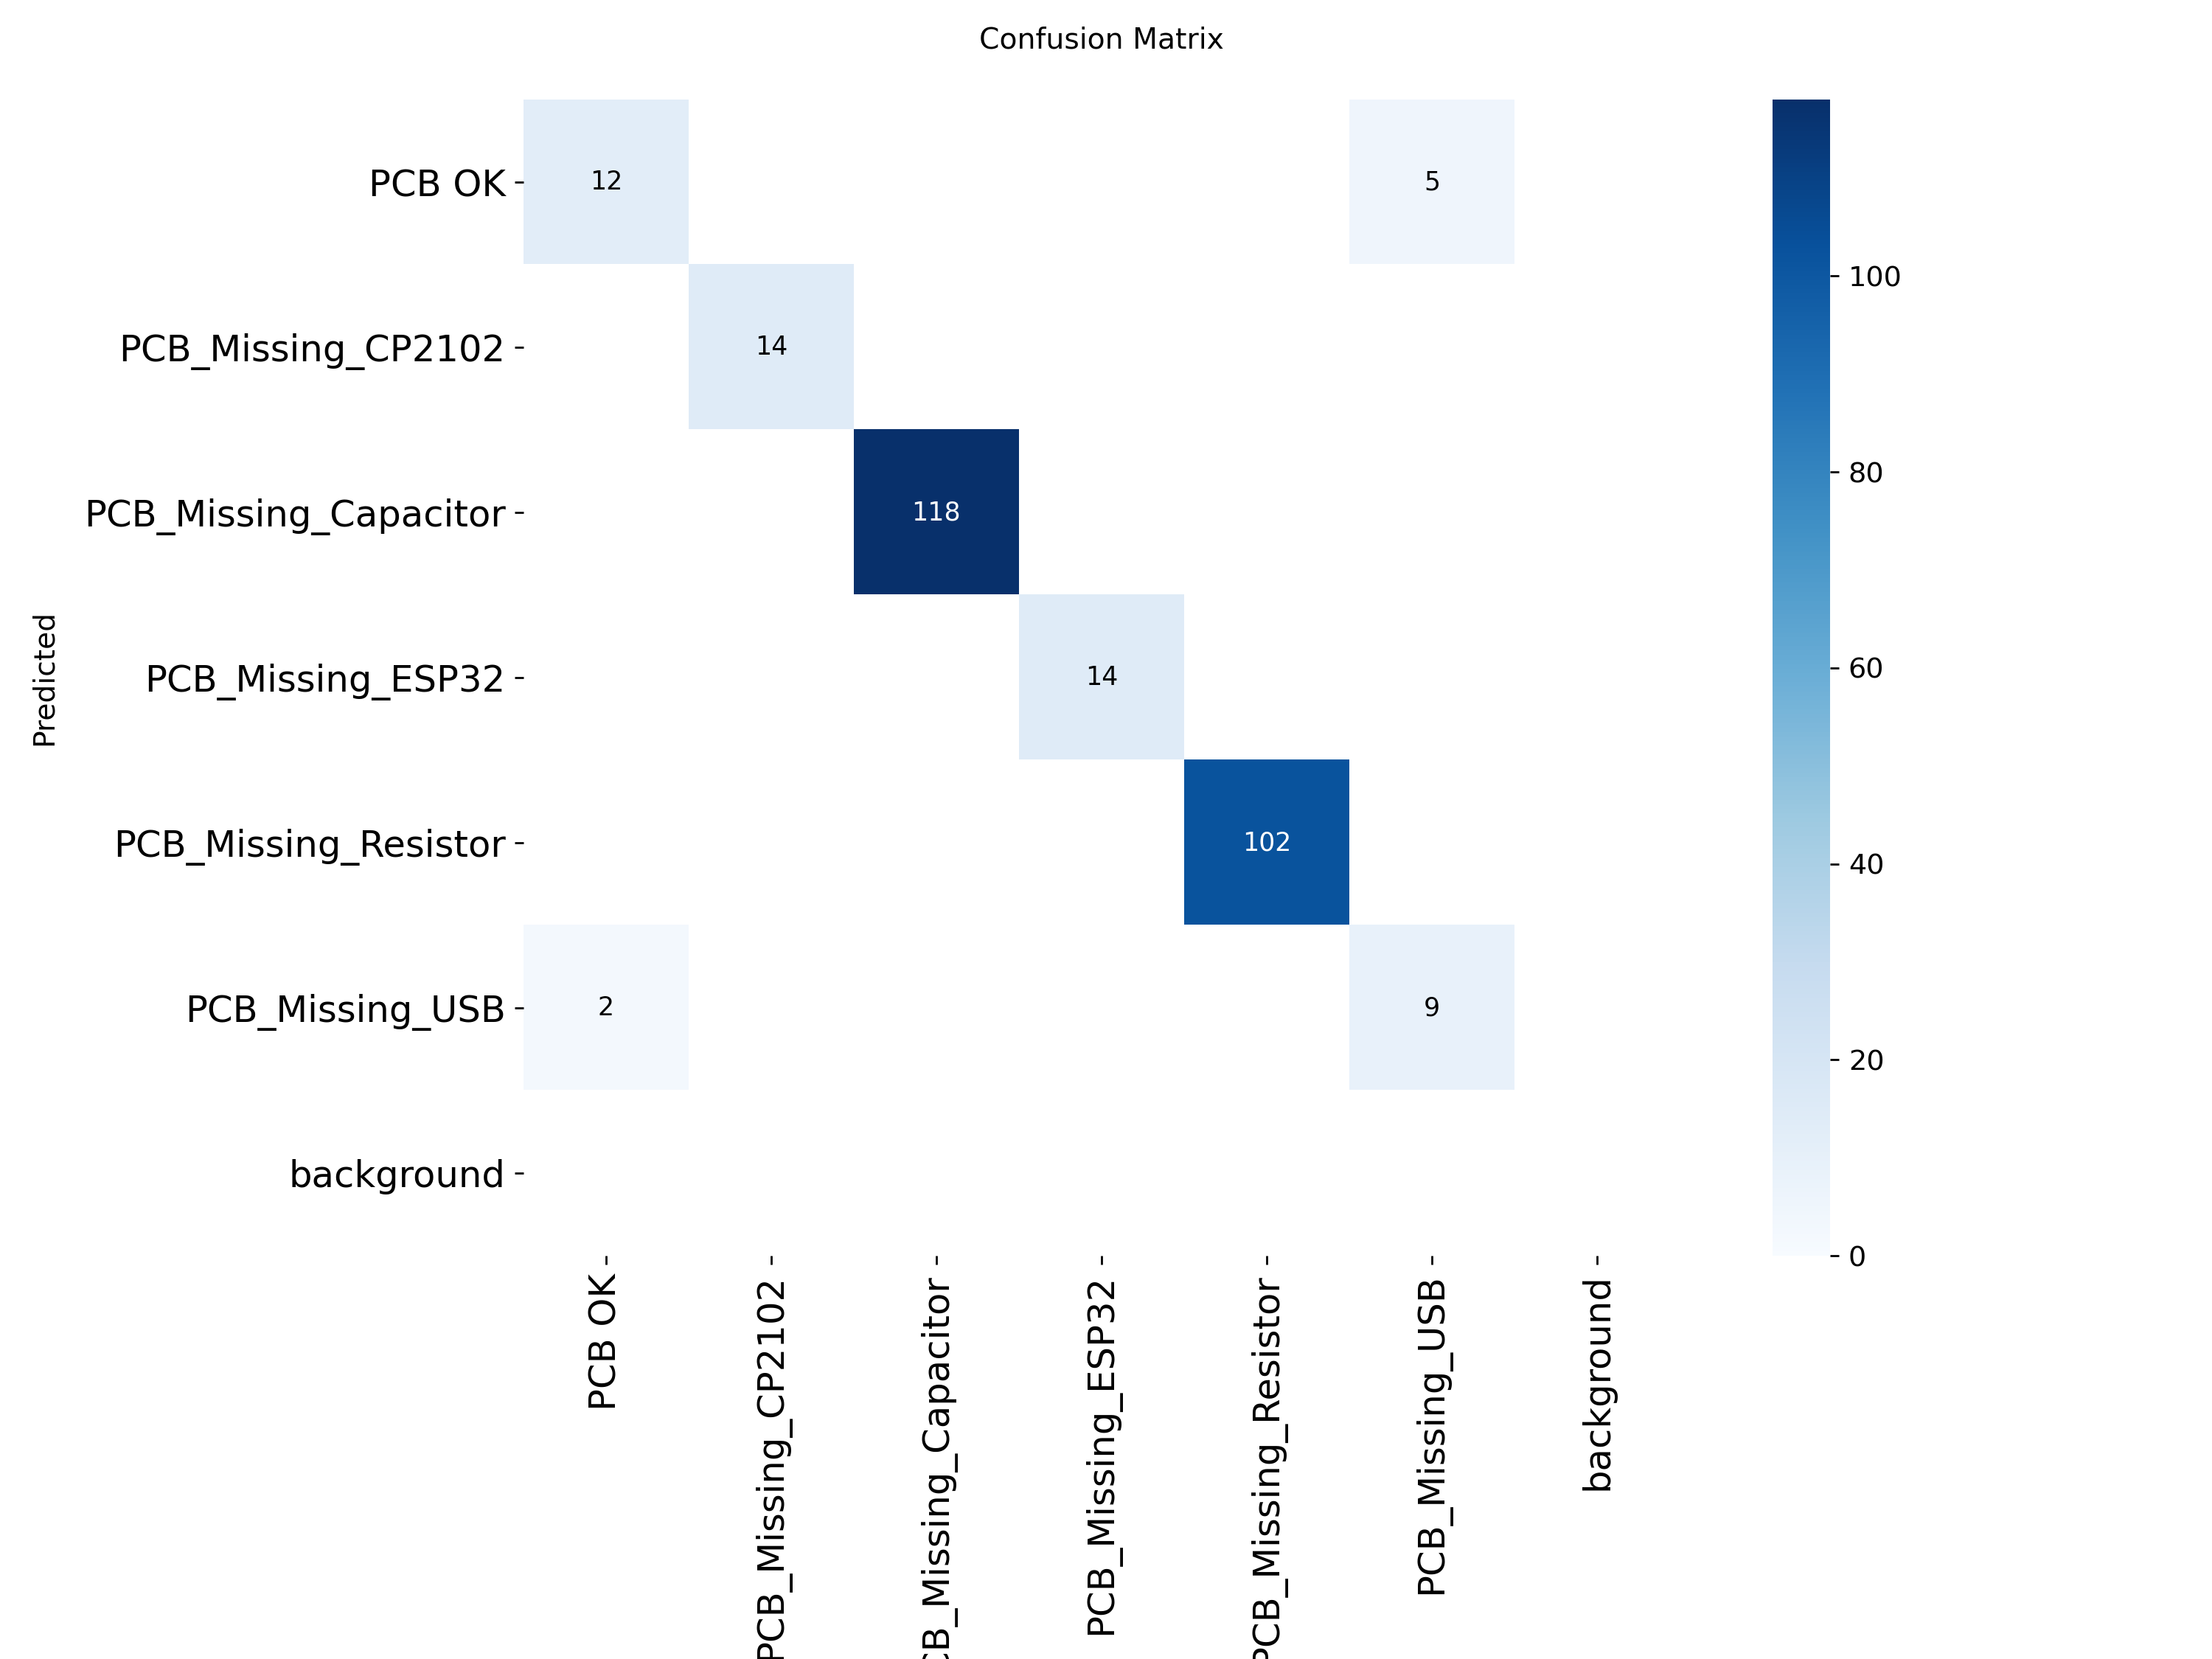

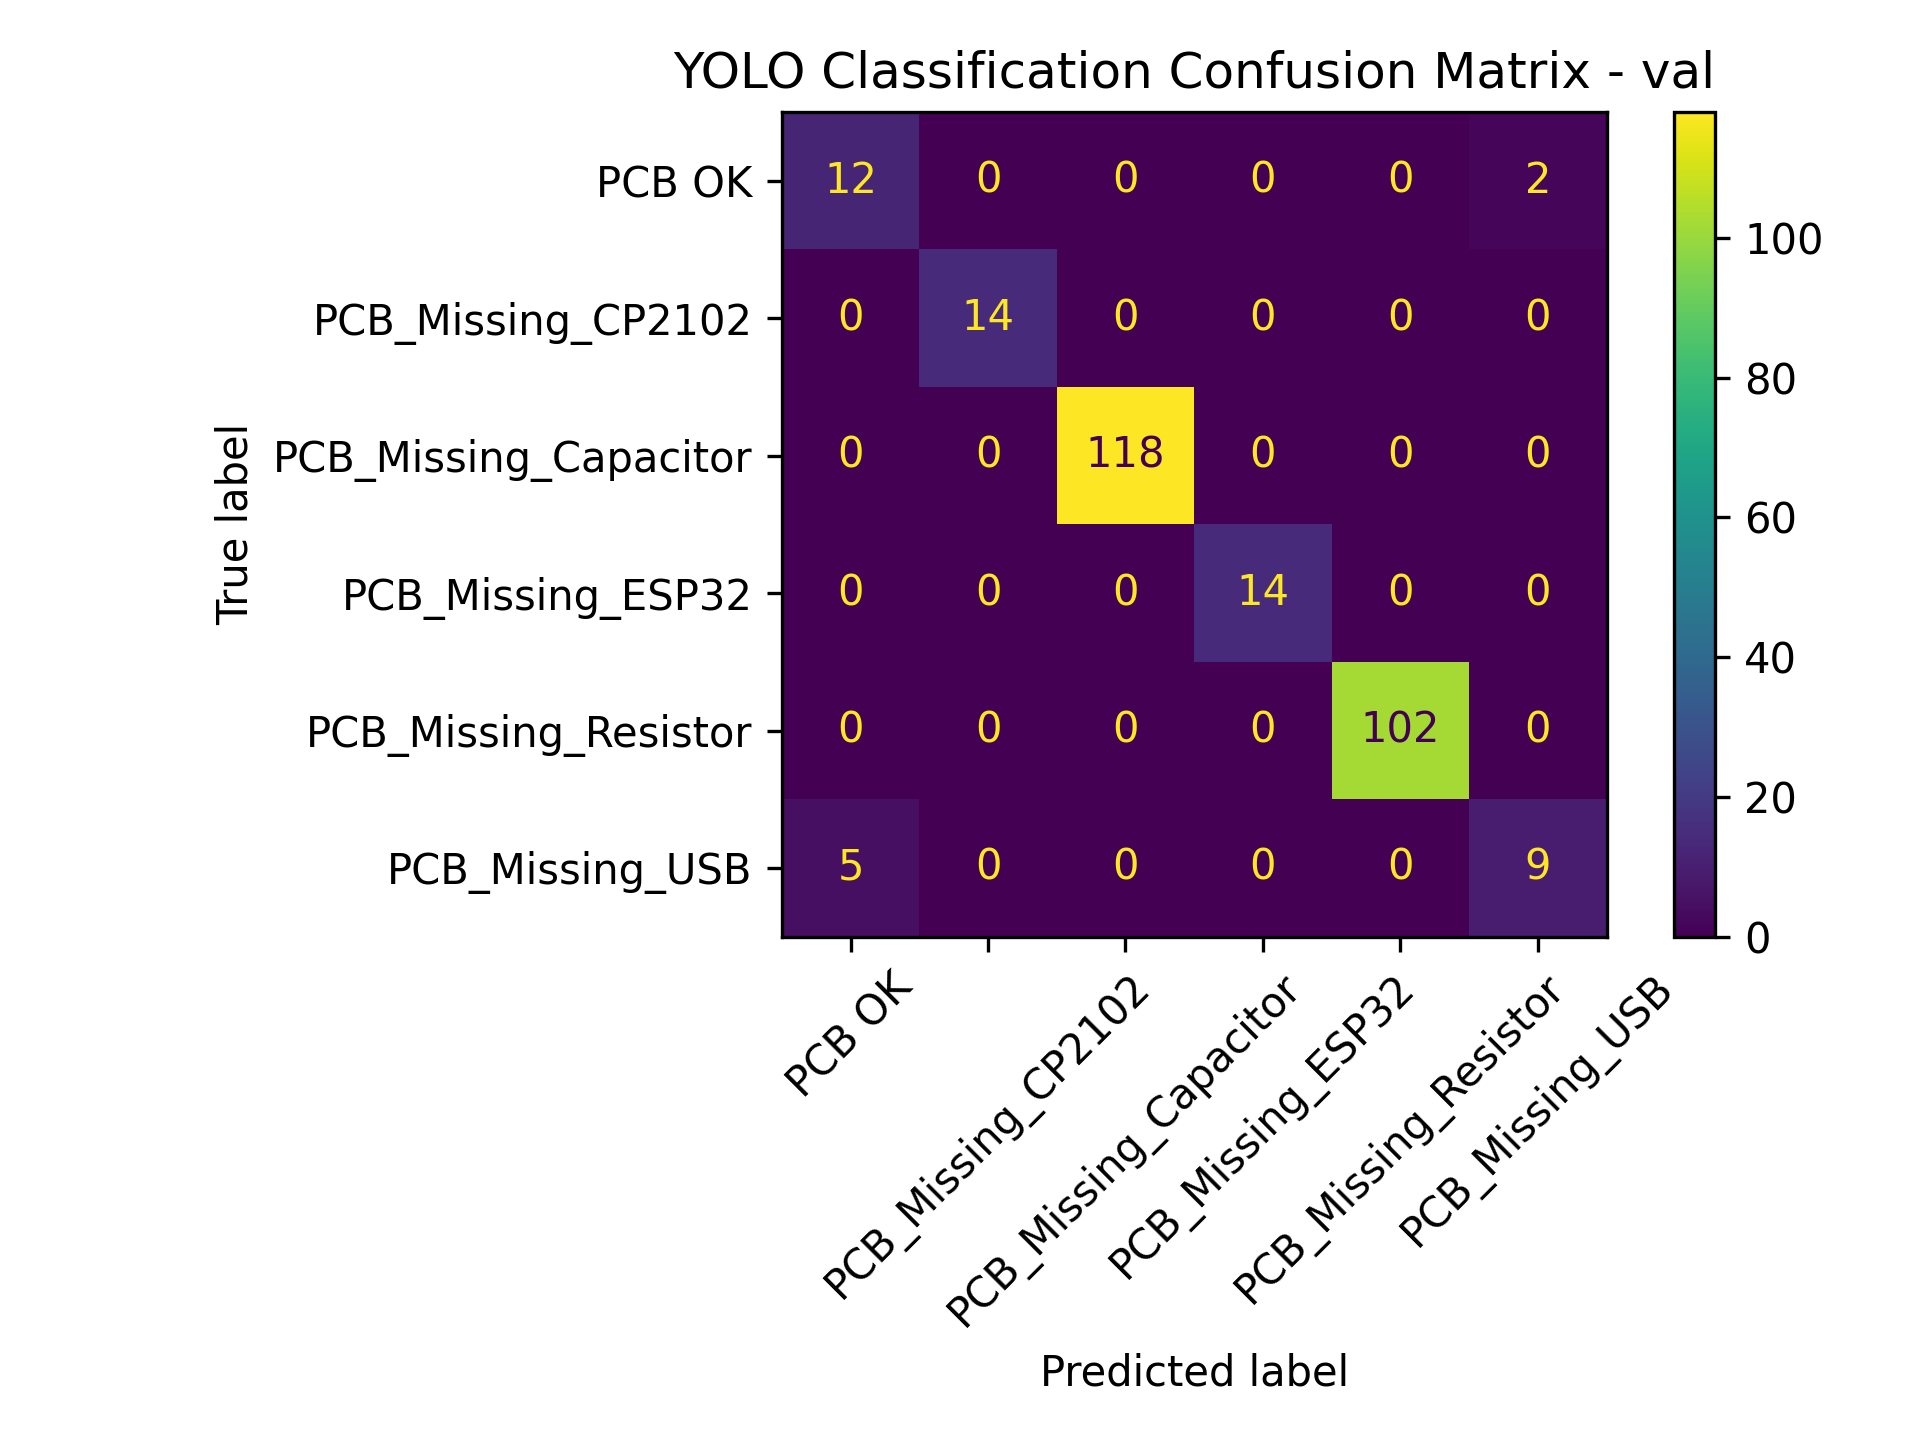

Các file chính:
best.pt: /content/drive/MyDrive/YOLO_Classification_Gan_Result/train/weights/best.pt
last.pt: /content/drive/MyDrive/YOLO_Classification_Gan_Result/train/weights/last.pt
results.png: /content/drive/MyDrive/YOLO_Classification_Gan_Result/train/results.png
results.csv: /content/drive/MyDrive/YOLO_Classification_Gan_Result/train/results.csv
metrics: /content/drive/MyDrive/YOLO_Classification_Gan_Result/train/classification_metrics_val.csv
report: /content/drive/MyDrive/YOLO_Classification_Gan_Result/train/classification_report_val.csv


In [7]:
display(Image(str(RESULT_DIR / "results.png")))
display(Image(str(RESULT_DIR / "confusion_matrix.png")))
display(Image(str(RESULT_DIR / f"classification_confusion_matrix_{split_name}.png")))

print("Các file chính:")
print("best.pt:", RESULT_DIR / "weights" / "best.pt")
print("last.pt:", RESULT_DIR / "weights" / "last.pt")
print("results.png:", RESULT_DIR / "results.png")
print("results.csv:", RESULT_DIR / "results.csv")
print("metrics:", RESULT_DIR / f"classification_metrics_{split_name}.csv")
print("report:", RESULT_DIR / f"classification_report_{split_name}.csv")